In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [4]:
import os

os.listdir()

['.config', 'Telco_customer_churn.xlsx', 'sample_data']

In [5]:
df = pd.read_excel("Telco_customer_churn.xlsx")

df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

df['Total Charges'] = df['Total Charges'].fillna(0)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  I

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


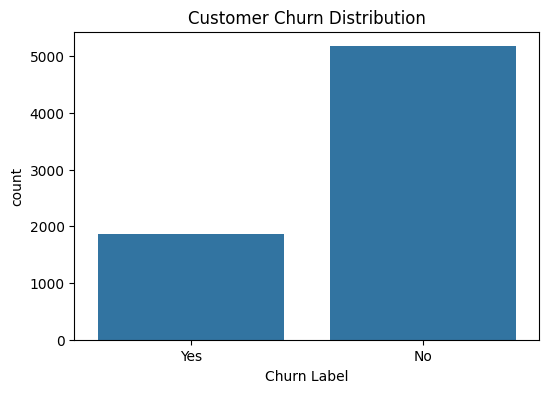

In [7]:
churn_counts = df['Churn Label'].value_counts()

print(churn_counts)
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn Label'
)

plt.title("Customer Churn Distribution")
plt.show()

# Approximately 26.5% of customers have churned while 73.5% remain active, indicating a moderate customer retention challenge.

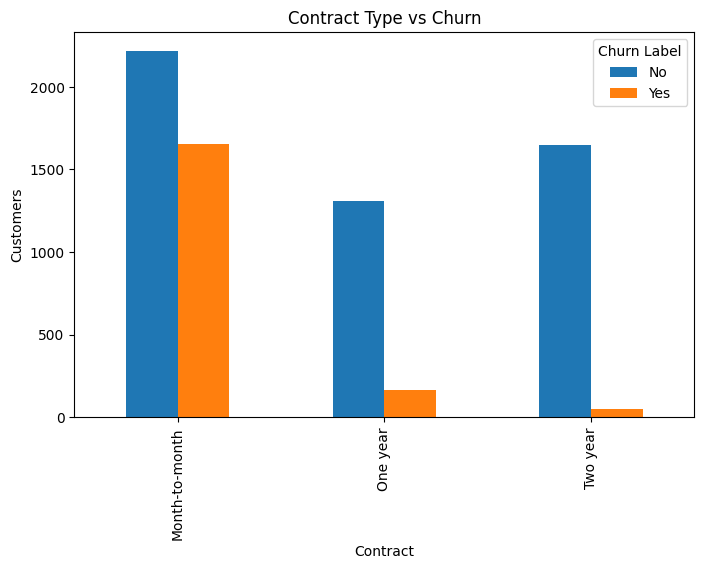

In [9]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Label']
)

contract_churn
contract_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.ylabel("Customers")
plt.show()

# Month-to-Month contracts contribute the largest share of churned customers.

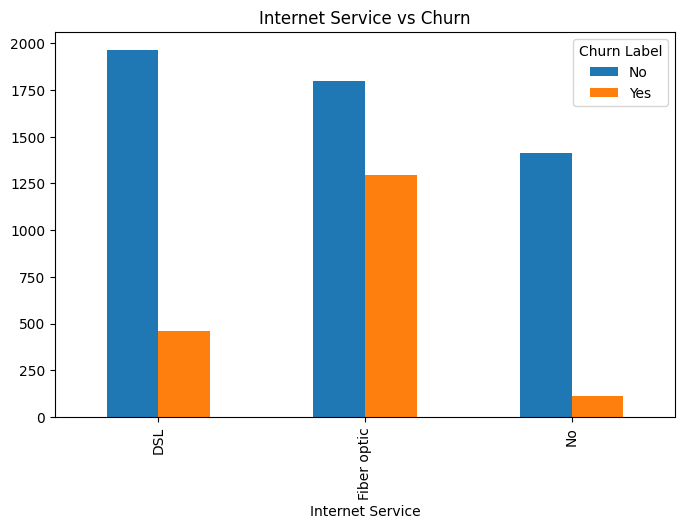

In [10]:
internet_churn = pd.crosstab(
    df['Internet Service'],
    df['Churn Label']
)

internet_churn
internet_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.show()

# Fiber Optic customers exhibit significantly higher churn compared to DSL and non-internet customers.

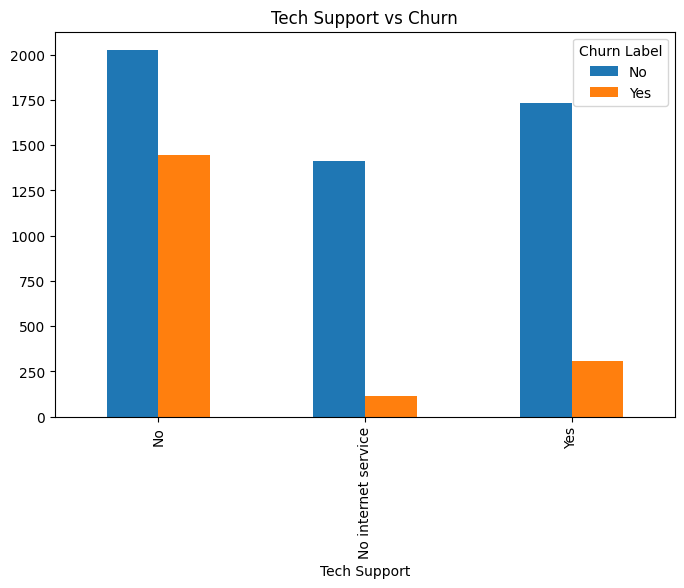

In [11]:
tech_churn = pd.crosstab(
    df['Tech Support'],
    df['Churn Label']
)

tech_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Tech Support vs Churn")
plt.show()

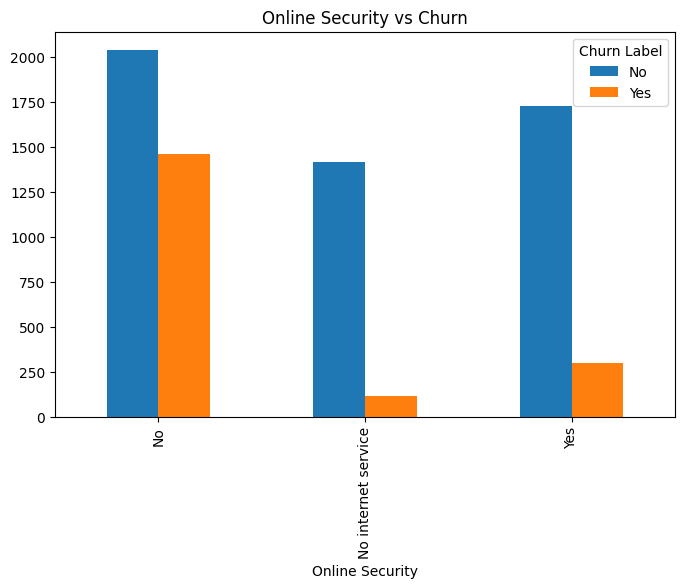

In [12]:
security_churn = pd.crosstab(
    df['Online Security'],
    df['Churn Label']
)

security_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Online Security vs Churn")
plt.show()

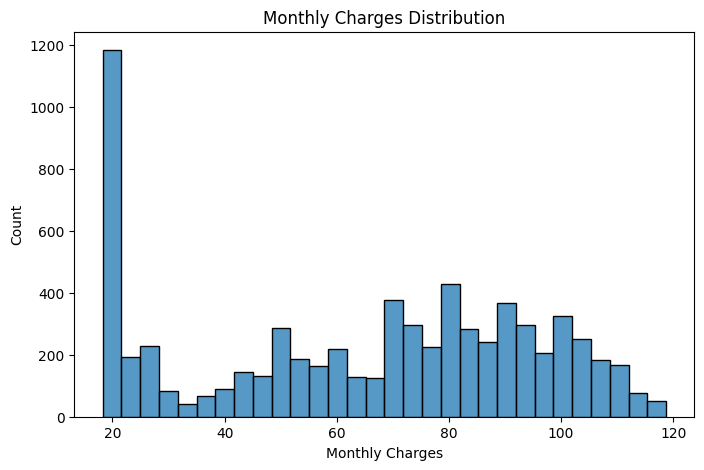

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Monthly Charges'],
    bins=30
)

plt.title("Monthly Charges Distribution")
plt.show()

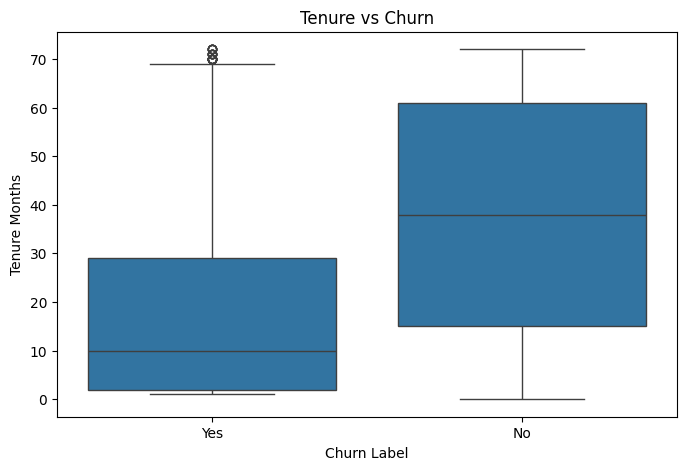

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn Label',
    y='Tenure Months'
)

plt.title("Tenure vs Churn")
plt.show()

# Customers with shorter tenure are more likely to churn.